# Part B: Gradient-Direction Sharpness Proxy

This notebook loads the Part A best-ID checkpoints and compares SGD vs SAM using a controlled gradient-direction perturbation analysis over fixed ID batches.

Main question: under the same local perturbation protocol, is the SAM checkpoint less sensitive than the SGD checkpoint?

This is a local sharpness proxy, not a complete Hessian analysis or a proof that flatness alone explains SAM's generalization.


## Part B Plan

We reuse the selected Part A checkpoints instead of retraining from scratch. To match the feedback, the primary analysis uses the best-ID checkpoint for each optimizer, because this part evaluates in-distribution CIFAR-10 batches.

We use two complementary views:

1. **Batch-averaged gradient-direction sharpness proxy**: for each batch, we move the parameters in the normalized gradient direction by a radius `rho`, then measure the loss increase.
2. **Fixed-rho batch comparison**: at a representative `rho`, we compare the sharpness-proxy distribution across multiple fixed batches.

If SAM consistently shows a smaller loss increase, we describe the result as lower local loss sensitivity under this perturbation protocol. We do not treat it as a full proof of globally flatter minima.


In [1]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
except ModuleNotFoundError:
    print('Not running in Colab; skipping Google Drive mount.')


Mounted at /content/drive


In [2]:
import os
import sys
from pathlib import Path

import pandas as pd

# Set PROJECT_ROOT in the environment if the notebook is not opened from the repo root.
PROJECT_ROOT = Path(os.environ.get('PROJECT_ROOT', Path.cwd())).expanduser().resolve()
COLAB_FALLBACK_ROOT = Path('/content/drive/MyDrive/Assignment2_SAM')

if not (PROJECT_ROOT / 'config.py').exists() and COLAB_FALLBACK_ROOT.exists():
    PROJECT_ROOT = COLAB_FALLBACK_ROOT

if not (PROJECT_ROOT / 'config.py').exists():
    raise FileNotFoundError(
        'Could not find config.py. Open this notebook from the repository root '
        'or set the PROJECT_ROOT environment variable.'
    )

os.chdir(PROJECT_ROOT)
project_root_str = str(PROJECT_ROOT)
if project_root_str not in sys.path:
    sys.path.append(project_root_str)

print('Current working directory:', os.getcwd())
print('Project files:', os.listdir(PROJECT_ROOT)[:10])


Current working directory: /content/drive/MyDrive/Assignment2_SAM
Project files: ['data.py', 'Run_PartA_Colab.ipynb', '.gitignore', 'plot_results.py', 'run_experiment.py', 'train.py', 'config.py', 'utils.py', 'models.py', 'sam.py']


In [3]:
import copy
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn as nn

from config import MODEL_NAME, SEED
from data import get_id_test_loader
from evaluate import evaluate
from models import get_model

torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
print("Model name from config:", MODEL_NAME)

Device: cuda
Model name from config: resnet18


In [4]:
CHECKPOINT_VARIANT = 'best_id'
checkpoint_files = {
    'SGD': f'sgd_resnet18_cifar10_{CHECKPOINT_VARIANT}.pt',
    'SAM': f'sam_resnet18_cifar10_{CHECKPOINT_VARIANT}.pt',
}

sgd_ckpt_path = PROJECT_ROOT / 'checkpoints' / checkpoint_files['SGD']
sam_ckpt_path = PROJECT_ROOT / 'checkpoints' / checkpoint_files['SAM']

print('Checkpoint variant:', CHECKPOINT_VARIANT)
print('SGD checkpoint:', sgd_ckpt_path)
print('SAM checkpoint:', sam_ckpt_path)

missing = [path for path in [sgd_ckpt_path, sam_ckpt_path] if not path.exists()]
if missing:
    raise FileNotFoundError(f'Missing checkpoint files: {missing}')

sgd_ckpt = torch.load(sgd_ckpt_path, map_location=device)
sam_ckpt = torch.load(sam_ckpt_path, map_location=device)

print('SGD checkpoint keys:', sgd_ckpt.keys())
print('SAM checkpoint keys:', sam_ckpt.keys())


Checkpoint variant: best_id
SGD checkpoint: /content/drive/MyDrive/Assignment2_SAM/checkpoints/sgd_resnet18_cifar10_best_id.pt
SAM checkpoint: /content/drive/MyDrive/Assignment2_SAM/checkpoints/sam_resnet18_cifar10_best_id.pt
SGD checkpoint keys: dict_keys(['optimizer_name', 'checkpoint_type', 'model_name', 'epoch', 'model_state_dict', 'optimizer_state_dict', 'metrics'])
SAM checkpoint keys: dict_keys(['optimizer_name', 'checkpoint_type', 'model_name', 'epoch', 'model_state_dict', 'optimizer_state_dict', 'metrics'])


In [5]:
sgd_model = get_model(MODEL_NAME).to(device)
sam_model = get_model(MODEL_NAME).to(device)

sgd_model.load_state_dict(sgd_ckpt["model_state_dict"])
sam_model.load_state_dict(sam_ckpt["model_state_dict"])

print("Both models loaded successfully.")


Both models loaded successfully.


In [6]:
id_loader = get_id_test_loader()
inputs, targets = next(iter(id_loader))

print("Input shape:", inputs.shape)
print("Target shape:", targets.shape)
print("Number of batches:", len(id_loader))


100%|██████████| 170M/170M [00:04<00:00, 34.8MB/s]


Input shape: torch.Size([128, 3, 32, 32])
Target shape: torch.Size([128])
Number of batches: 79


## Baseline Metrics

This sanity-check step confirms that the loaded best-ID checkpoints reproduce the expected Part A test metrics. If these values differ from the saved Part A CSVs, the checkpoint selection should be checked before interpreting Part B.


In [7]:
criterion = nn.CrossEntropyLoss()

sgd_base = evaluate(sgd_model, id_loader, criterion, device)
sam_base = evaluate(sam_model, id_loader, criterion, device)

print("SGD baseline:", sgd_base)
print("SAM baseline:", sam_base)


SGD baseline: {'loss': 0.3890850368499756, 'accuracy': 0.8682}
SAM baseline: {'loss': 0.36116332416534425, 'accuracy': 0.8758}


## Build Fixed Analysis Batches

We use a small fixed set of ID batches so that both models are compared on exactly the same inputs. This reduces randomness and makes the SGD vs SAM comparison more stable.


In [8]:
def collect_fixed_batches(data_loader, num_batches=10):
    batches = []
    for batch_index, batch in enumerate(data_loader):
        batches.append(batch)
        if batch_index + 1 >= num_batches:
            break
    return batches


analysis_batches = collect_fixed_batches(id_loader, num_batches=10)
print("Collected batches:", len(analysis_batches))

Collected batches: 10


## Batch-Averaged Gradient-Direction Sharpness Proxy

For each batch, we compute the batch loss, move parameters along the normalized gradient direction by a radius `rho`, and measure the loss increase on the same batch. We then average across fixed batches.

Why this definition is useful for this part:

- it follows the local gradient-aligned direction used by the SAM perturbation idea,
- it gives a controlled local loss-sensitivity measure,
- and averaging over several fixed batches makes the comparison less dependent on one batch.

Important limitation: this proxy is not a full Hessian estimate and not a worst-case search over every possible parameter direction.


In [9]:
def get_batch_loss(model, batch, criterion, device):
    model.eval()
    inputs, targets = batch
    inputs = inputs.to(device)
    targets = targets.to(device)
    outputs = model(inputs)
    return criterion(outputs, targets)


def measure_batch_gradient_sharpness(model, batch, criterion, device, rho=0.05):
    original_state = copy.deepcopy(model.state_dict())
    model.zero_grad()

    base_loss_tensor = get_batch_loss(model, batch, criterion, device)
    base_loss = base_loss_tensor.item()
    base_loss_tensor.backward()

    params = [p for p in model.parameters() if p.requires_grad and p.grad is not None]
    grad_norm = torch.sqrt(sum(torch.sum(p.grad ** 2) for p in params))

    with torch.no_grad():
        for param in params:
            param.add_(rho * param.grad / (grad_norm + 1e-12))

    perturbed_loss = get_batch_loss(model, batch, criterion, device).item()
    model.load_state_dict(original_state)

    return {
        "rho": rho,
        "base_loss": base_loss,
        "perturbed_loss": perturbed_loss,
        "sharpness": perturbed_loss - base_loss,
    }


def measure_dataset_gradient_sharpness(model, batches, criterion, device, rho=0.05):
    per_batch_rows = []

    for batch_index, batch in enumerate(batches):
        metrics = measure_batch_gradient_sharpness(model, batch, criterion, device, rho=rho)
        per_batch_rows.append({"batch_index": batch_index, **metrics})

    per_batch_df = pd.DataFrame(per_batch_rows)
    summary = {
        "rho": rho,
        "mean_base_loss": per_batch_df["base_loss"].mean(),
        "mean_perturbed_loss": per_batch_df["perturbed_loss"].mean(),
        "mean_sharpness": per_batch_df["sharpness"].mean(),
        "std_sharpness": per_batch_df["sharpness"].std(ddof=0),
    }
    return summary, per_batch_df


def run_dataset_sharpness_sweep(model, model_name, batches, criterion, device, rhos):
    summary_rows = []
    per_batch_frames = []

    for rho in rhos:
        summary, per_batch_df = measure_dataset_gradient_sharpness(
            model, batches, criterion, device, rho=rho
        )
        summary_row = {"model": model_name, **summary}
        summary_rows.append(summary_row)

        per_batch_df = per_batch_df.copy()
        per_batch_df["model"] = model_name
        per_batch_frames.append(per_batch_df)

        print(summary_row)

    return pd.DataFrame(summary_rows), pd.concat(per_batch_frames, ignore_index=True)


In [10]:
rhos = [0.001, 0.005, 0.01, 0.05]

sgd_grad_df, sgd_per_batch_df = run_dataset_sharpness_sweep(
    sgd_model, 'SGD', analysis_batches, criterion, device, rhos
)
sam_grad_df, sam_per_batch_df = run_dataset_sharpness_sweep(
    sam_model, 'SAM', analysis_batches, criterion, device, rhos
)

grad_df = pd.concat([sgd_grad_df, sam_grad_df], ignore_index=True)
per_batch_df = pd.concat([sgd_per_batch_df, sam_per_batch_df], ignore_index=True)

for df in [grad_df, per_batch_df]:
    if 'checkpoint_variant' not in df.columns:
        df.insert(1, 'checkpoint_variant', CHECKPOINT_VARIANT)

grad_df


{'model': 'SGD', 'rho': 0.001, 'mean_base_loss': np.float64(0.3532644331455231), 'mean_perturbed_loss': np.float64(0.3559363543987274), 'mean_sharpness': np.float64(0.002671921253204346), 'std_sharpness': 0.0005344156969104901}
{'model': 'SGD', 'rho': 0.005, 'mean_base_loss': np.float64(0.3532644331455231), 'mean_perturbed_loss': np.float64(0.3669426470994949), 'mean_sharpness': np.float64(0.013678213953971863), 'std_sharpness': 0.002721437302711081}
{'model': 'SGD', 'rho': 0.01, 'mean_base_loss': np.float64(0.3532644331455231), 'mean_perturbed_loss': np.float64(0.38139522075653076), 'mean_sharpness': np.float64(0.02813078761100769), 'std_sharpness': 0.0055497122840682455}
{'model': 'SGD', 'rho': 0.05, 'mean_base_loss': np.float64(0.3532644331455231), 'mean_perturbed_loss': np.float64(0.5215689748525619), 'mean_sharpness': np.float64(0.16830454170703887), 'std_sharpness': 0.03220539846795684}
{'model': 'SAM', 'rho': 0.001, 'mean_base_loss': np.float64(0.3729786515235901), 'mean_perturb

,model,checkpoint_variant,rho,mean_base_loss,mean_perturbed_loss,mean_sharpness,std_sharpness
0,SGD,best_id,0.001,0.353264,0.355936,0.002672,0.000534
1,SGD,best_id,0.005,0.353264,0.366943,0.013678,0.002721
2,SGD,best_id,0.010,0.353264,0.381395,0.028131,0.005550
3,SGD,best_id,0.050,0.353264,0.521569,0.168305,0.032205
4,SAM,best_id,0.001,0.372979,0.375491,0.002512,0.000293
5,SAM,best_id,0.005,0.372979,0.385755,0.012776,0.001512
6,SAM,best_id,0.010,0.372979,0.399082,0.026103,0.003138
7,SAM,best_id,0.050,0.372979,0.522611,0.149633,0.019846


### Interpretation Guide for `grad_df`

The most important column is `mean_sharpness`.

- Smaller `mean_sharpness` means the loss increases less after the local gradient-direction perturbation.
- If SAM has consistently smaller `mean_sharpness` than SGD across all `rho`, that supports a narrower claim: SAM has lower local loss sensitivity under this proxy.
- `std_sharpness` tells us how much this effect varies across fixed batches.


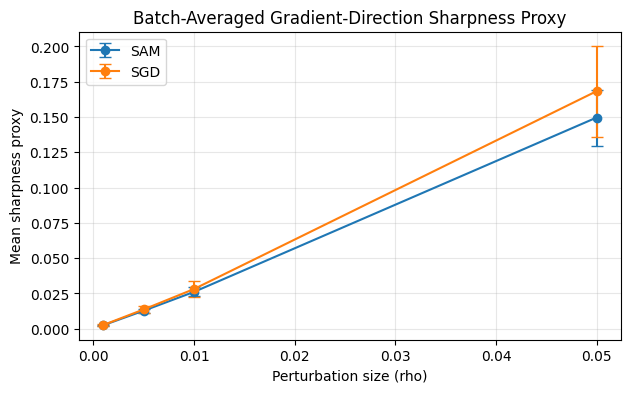

In [11]:
plt.figure(figsize=(7, 4))
for model_name, group in grad_df.groupby('model'):
    plt.errorbar(
        group['rho'],
        group['mean_sharpness'],
        yerr=group['std_sharpness'],
        marker='o',
        capsize=4,
        label=model_name,
    )

plt.xlabel('Perturbation size (rho)')
plt.ylabel('Mean sharpness proxy')
plt.title('Batch-Averaged Gradient-Direction Sharpness Proxy')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


### How to Read the Main Figure

A lower curve means lower local loss sensitivity under the gradient-direction perturbation. If the SAM curve stays below the SGD curve as `rho` grows, then SAM is consistently less sensitive to this controlled perturbation protocol.


## Fixed-Rho Batch Comparison

This gives a second view by comparing the batch-wise sharpness-proxy distribution at a representative perturbation radius. We use `rho = 0.01` because it is large enough to show a clear difference while remaining smaller than the Part A SAM training radius (`SAM_RHO = 0.05`).


In [12]:
focus_rho = 0.01
focus_df = per_batch_df[per_batch_df["rho"] == focus_rho].copy()
focus_df


,batch_index,checkpoint_variant,rho,base_loss,perturbed_loss,sharpness,model
20,0,best_id,0.01,0.261302,0.282705,0.021403,SGD
21,1,best_id,0.01,0.390884,0.415938,0.025055,SGD
22,2,best_id,0.01,0.273135,0.297292,0.024157,SGD
23,3,best_id,0.01,0.287520,0.313519,0.025999,SGD
24,4,best_id,0.01,0.217021,0.245421,0.028400,SGD
25,5,best_id,0.01,0.438995,0.465544,0.026550,SGD
26,6,best_id,0.01,0.471875,0.505085,0.033210,SGD
27,7,best_id,0.01,0.287710,0.311952,0.024242,SGD
28,8,best_id,0.01,0.571691,0.613358,0.041667,SGD
29,9,best_id,0.01,0.332511,0.363137,0.030626,SGD


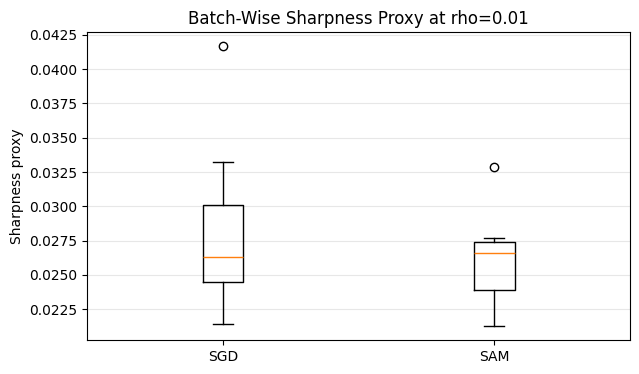

In [13]:
plt.figure(figsize=(7, 4))
plot_data = [
    focus_df[focus_df['model'] == 'SGD']['sharpness'],
    focus_df[focus_df['model'] == 'SAM']['sharpness'],
]

plt.boxplot(plot_data, tick_labels=['SGD', 'SAM'])
plt.ylabel('Sharpness proxy')
plt.title(f'Batch-Wise Sharpness Proxy at rho={focus_rho}')
plt.grid(True, axis='y', alpha=0.3)
plt.show()


In [14]:
focus_summary = (
    focus_df.groupby('model')['sharpness']
    .agg(['mean', 'std', 'min', 'max'])
    .reset_index()
)

if 'checkpoint_variant' not in focus_summary.columns:
    focus_summary.insert(1, 'checkpoint_variant', CHECKPOINT_VARIANT)

focus_summary


,model,checkpoint_variant,mean,std,min,max
0,SAM,best_id,0.026103,0.003308,0.021244,0.032843
1,SGD,best_id,0.028131,0.005850,0.021403,0.041667


### Interpretation Guide for the Boxplot

This figure checks whether the main conclusion also holds batch-by-batch.

- If the SAM box is lower than the SGD box, then SAM tends to have lower local sensitivity on most fixed batches, not just on average.
- The table below the boxplot gives a compact numerical summary of the same pattern.


## Suggested Write-Up Notes

You can reuse this logic in the report:

- We evaluated local loss sensitivity using a gradient-direction perturbation sharpness proxy on fixed in-distribution CIFAR-10 test batches.
- The primary analysis used the Part A best-ID checkpoints, rather than only the final epoch checkpoints.
- For each batch, we perturbed the parameters in the normalized gradient direction and measured the increase in cross-entropy loss.
- We swept multiple `rho` values to check whether the conclusion was stable across perturbation sizes.
- If SAM remains below SGD across the sweep, the result supports the claim that SAM is less sensitive to local gradient-aligned parameter perturbations.
- We do not claim that this proxy is a full Hessian analysis or that flatness alone completely explains SAM's generalization behavior.


## References

- Foret, P., Kleiner, A., Mobahi, H., & Neyshabur, B. (2021). *Sharpness-Aware Minimization for Efficiently Improving Generalization*. ICLR 2021. https://openreview.net/forum?id=6Tm1mposlrM
- Andriushchenko, M., & Flammarion, N. (2022). *Towards Understanding Sharpness-Aware Minimization*. ICML 2022. https://proceedings.mlr.press/v162/andriushchenko22a.html
- Kaur, S., Cohen, J., & Lipton, Z. C. (2023). *On the Maximum Hessian Eigenvalue and Generalization*. PMLR 187. https://proceedings.mlr.press/v187/kaur23a.html
- Wen, K., Li, Z., & Ma, T. (2023). *Sharpness Minimization Algorithms Do Not Only Minimize Sharpness To Achieve Better Generalization*. NeurIPS 2023. https://papers.nips.cc/paper_files/paper/2023/hash/0354767c6386386be17cabe4fc59711b-Abstract-Conference.html
- Mueller, M., Vlaar, T., Rolnick, D., & Hein, M. (2023). *Normalization Layers Are All That Sharpness-Aware Minimization Needs*. arXiv:2306.04226. https://arxiv.org/abs/2306.04226


## Save Part B Results

This step writes the key CSVs and figures into the `part_b/` folder so they can be reused in the final report.


In [15]:
part_b_dir = Path(PROJECT_ROOT) / 'part_b'
part_b_dir.mkdir(parents=True, exist_ok=True)

grad_df.to_csv(part_b_dir / 'batch_averaged_gradient_sharpness.csv', index=False)
per_batch_df.to_csv(part_b_dir / 'batch_level_gradient_sharpness.csv', index=False)
focus_summary.to_csv(part_b_dir / 'focus_rho_summary.csv', index=False)

plt.figure(figsize=(7, 4))
for model_name, group in grad_df.groupby('model'):
    plt.errorbar(
        group['rho'],
        group['mean_sharpness'],
        yerr=group['std_sharpness'],
        marker='o',
        capsize=4,
        label=model_name,
    )
plt.xlabel('Perturbation size (rho)')
plt.ylabel('Mean sharpness proxy')
plt.title('Batch-Averaged Gradient-Direction Sharpness Proxy')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(part_b_dir / 'batch_averaged_gradient_sharpness.png', dpi=300)
plt.close()

plt.figure(figsize=(7, 4))
plot_data = [
    focus_df[focus_df['model'] == 'SGD']['sharpness'],
    focus_df[focus_df['model'] == 'SAM']['sharpness'],
]
plt.boxplot(plot_data, tick_labels=['SGD', 'SAM'])
plt.ylabel('Sharpness proxy')
plt.title(f'Batch-Wise Sharpness Proxy at rho={focus_rho}')
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(part_b_dir / 'batchwise_sharpness_boxplot.png', dpi=300)
plt.close()

print('Saved files:')
for name in [
    'batch_averaged_gradient_sharpness.csv',
    'batch_level_gradient_sharpness.csv',
    'focus_rho_summary.csv',
    'batch_averaged_gradient_sharpness.png',
    'batchwise_sharpness_boxplot.png',
]:
    print(part_b_dir / name)


Saved files:
/content/drive/MyDrive/Assignment2_SAM/part_b/batch_averaged_gradient_sharpness.csv
/content/drive/MyDrive/Assignment2_SAM/part_b/batch_level_gradient_sharpness.csv
/content/drive/MyDrive/Assignment2_SAM/part_b/focus_rho_summary.csv
/content/drive/MyDrive/Assignment2_SAM/part_b/batch_averaged_gradient_sharpness.png
/content/drive/MyDrive/Assignment2_SAM/part_b/batchwise_sharpness_boxplot.png
